# 03 — Clustering (K-Means)

**Input:** `data/processed/processed_data.csv`  
**Output:** `data/processed/clustered_data.csv`, `models/kmeans_model.pkl`

In [15]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pickle
import warnings
warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/cluster')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
df = pd.read_csv('../data/processed/processed_data.csv')
print("processed data shape:", df.shape)

# Drop target (BuyLaptop) for clustering — clustering is unsupervised
if 'BuyLaptop' in df.columns:
    df_features = df.drop(columns=['BuyLaptop'])
    target = df['BuyLaptop']
    print(f'✓ Dropped BuyLaptop for clustering | Features shape: {df_features.shape}')

processed data shape: (8068, 9)
✓ Dropped BuyLaptop for clustering | Features shape: (8068, 8)


# Elbow Method

In [17]:
inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_features)  # Use features only, not target
    inertias.append(km.inertia_)

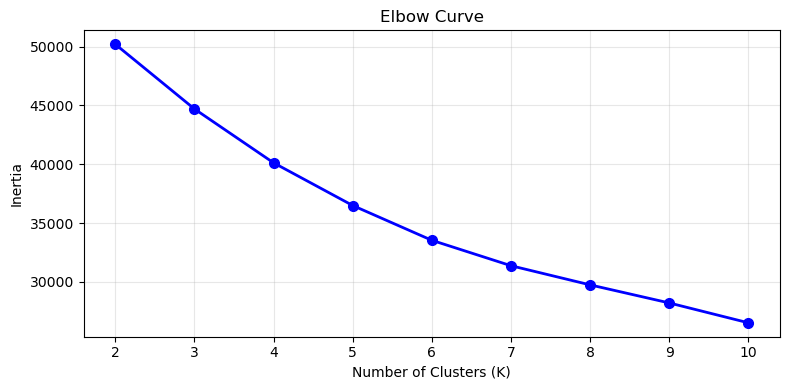

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'elbow_curve.png', dpi=150)
plt.show()

In [19]:
# From the elbow curve, we can see that the optimal number of clusters is around 4 or 5. Let's choose K=5 for our final model.
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_features)  # Fit on features only

print('Cluster distribution:')
print(pd.Series(clusters).value_counts().sort_index())

Cluster distribution:
0    1567
1    1630
2    1721
3    2249
4     901
Name: count, dtype: int64


# PCA visualization

In [20]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(df_features)  # Use features only
pca_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

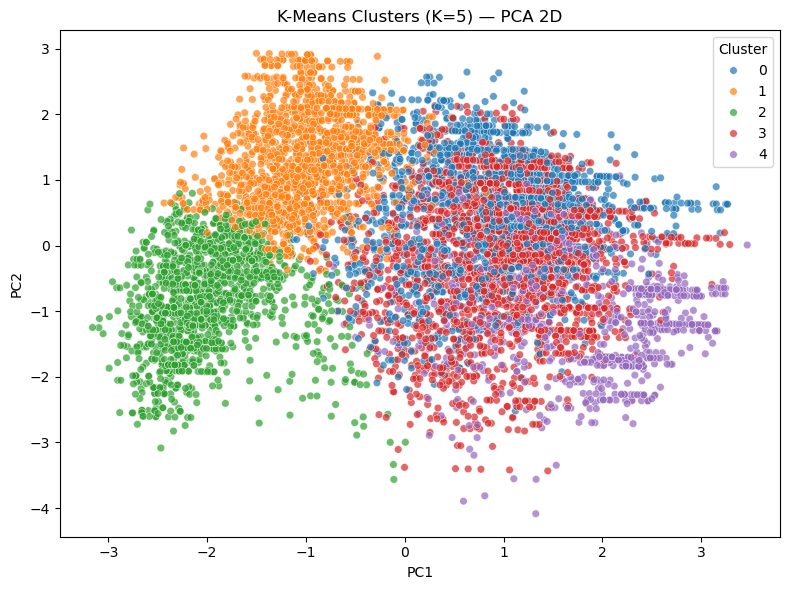

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7, s=30)
plt.title(f'K-Means Clusters (K={k_optimal}) — PCA 2D')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cluster_scatter.png', dpi=150)
plt.show()

# save clustered data and model

In [22]:
raw = pd.read_csv('../data/raw/raw_data.csv')
raw['Cluster'] = clusters
raw.to_csv('../data/processed/clustered_data.csv', index=False)
print('Saved clustered_data.csv — shape:', raw.shape)

Saved clustered_data.csv — shape: (8068, 11)


In [23]:
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print('Saved kmeans_model.pkl')

Saved kmeans_model.pkl


In [24]:
# Cluster profiles
print('\nCluster Profiles:')
print(raw.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].mean().round(2))



Cluster Profiles:
           Age  Work_Experience  Family_Size
Cluster                                     
0        47.02             2.76         2.77
1        37.39             3.76         1.85
2        26.48             2.34         4.18
3        46.49             2.54         2.94
4        73.21             1.16         2.05


In [25]:
# Calculate cluster quality metrics
silhouette = silhouette_score(df_features, clusters)  # Use features only
davies_bouldin = davies_bouldin_score(df_features, clusters)
calinski_harabasz = calinski_harabasz_score(df_features, clusters)

print('=== Cluster Quality Metrics ===')
print(f'Silhouette Score: {silhouette:.4f}')
print(f'  → Range [-1, 1]: >0.5 = good, >0.7 = excellent')
print(f'\nDavies-Bouldin Index: {davies_bouldin:.4f}')
print(f'  → Range [0, ∞]: Lower is better, <1 = excellent')
print(f'\nCalinski-Harabasz Index: {calinski_harabasz:.4f}')
print(f'  → Range [0, ∞]: Higher is better, >30 = good')
print('\n✓ Clustering quality validated!' if silhouette > 0.5 else '\n⚠ Consider different K value')

=== Cluster Quality Metrics ===
Silhouette Score: 0.2013
  → Range [-1, 1]: >0.5 = good, >0.7 = excellent

Davies-Bouldin Index: 1.7719
  → Range [0, ∞]: Lower is better, <1 = excellent

Calinski-Harabasz Index: 1549.2880
  → Range [0, ∞]: Higher is better, >30 = good

⚠ Consider different K value
